EMCEE LINE_2

In [ ]:
!pip install emcee
!pip install corner

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import emcee
import corner

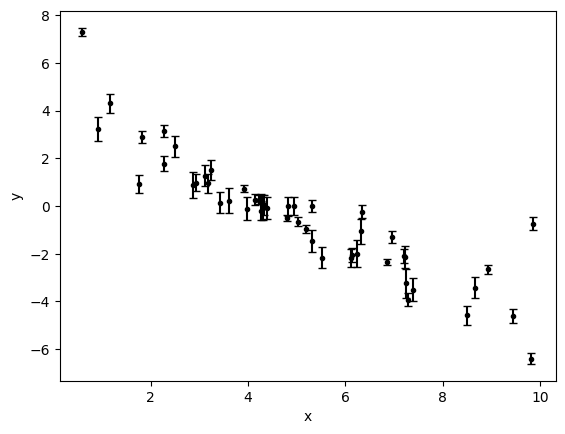

In [ ]:
data = np.loadtxt("/content/line-2.dat")

x = data[0]
y = data[1]
yerr = data[2]

x0 = np.linspace(np.min(x), np.max(x), 500)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Least-squares estimates:
m = -1.035 ± 0.016
b = 4.988 ± 0.091


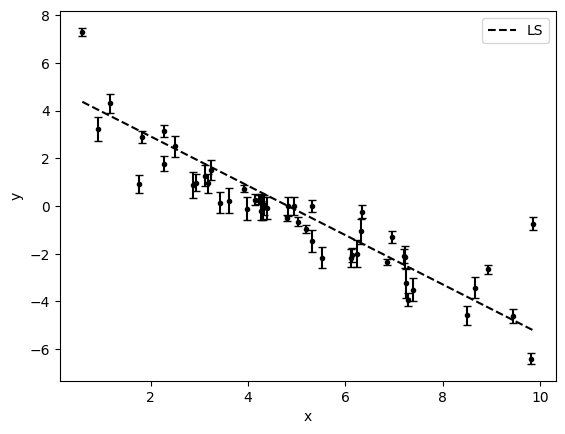

In [ ]:
A = np.vander(x, 2)
ATA = np.dot(A.T, A / (yerr**2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr**2))

m_ls = w[0]
b_ls = w[1]

print("Least-squares estimates:")
print("m = {:.3f} ± {:.3f}".format(m_ls, np.sqrt(cov[0, 0])))
print("b = {:.3f} ± {:.3f}".format(b_ls, np.sqrt(cov[1, 1])))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3)
plt.plot(x0, m_ls*x0 + b_ls, "--k", label="LS")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m*x + b
    sigma2 = yerr**2 + model**2 * np.exp(2*log_f)
    return -0.5*np.sum((y - model)**2/sigma2 + np.log(sigma2))

Maximum likelihood estimates:
m = -0.950
b = 4.220
f = 0.416


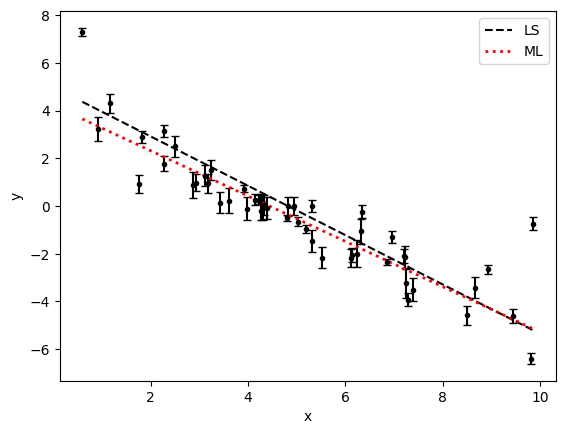

In [ ]:
np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)

initial = np.array([m_ls, b_ls, np.log(0.1)])

soln = minimize(nll, initial, args=(x, y, yerr))

m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {:.3f}".format(m_ml))
print("b = {:.3f}".format(b_ml))
print("f = {:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3)
plt.plot(x0, m_ls*x0 + b_ls, "--k", label="LS")
plt.plot(x0, m_ml*x0 + b_ml, ":r", lw=2, label="ML")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

In [ ]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [ ]:
pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:09<00:00, 511.17it/s]


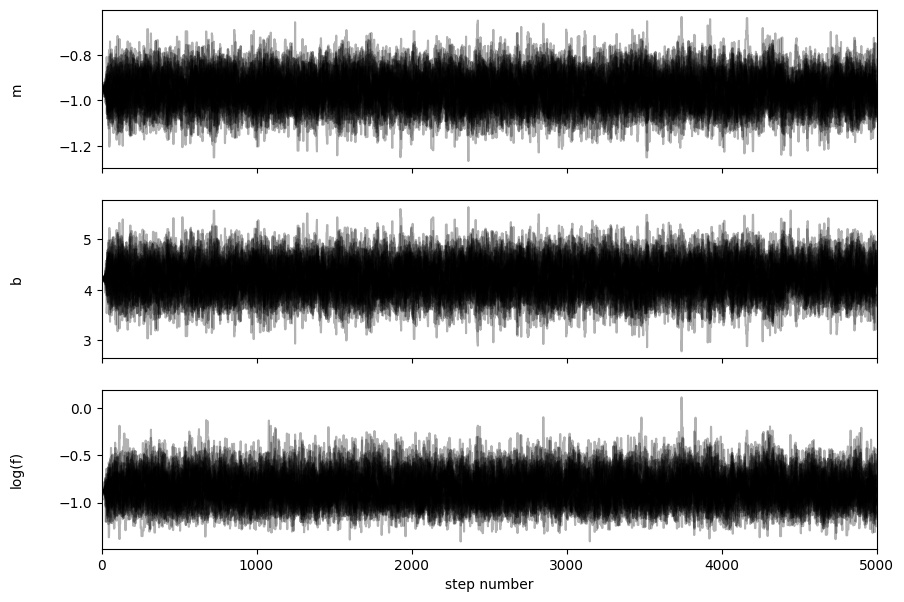

In [ ]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

[35.64875487 35.42316131 34.31903982]


In [ ]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 3)


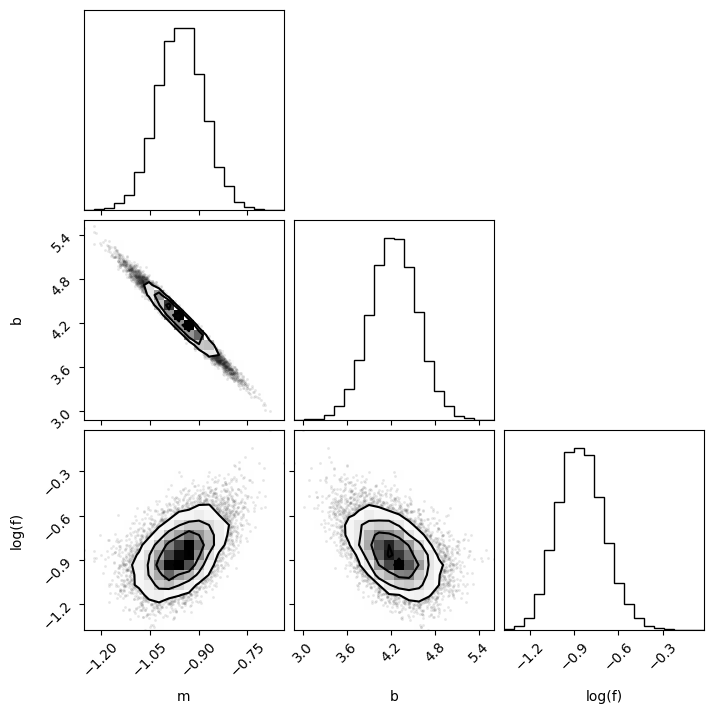

In [ ]:
corner.corner(flat_samples, labels=labels)
plt.show()

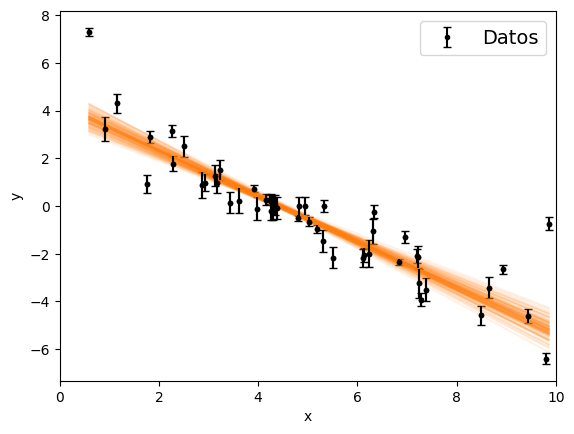

In [ ]:
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3, label="Datos")

inds = np.random.randint(len(flat_samples), size=100)

for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)

plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");